---
# Create input file for CESM3-CISM
- Author: Jiang Zhu (jiangzhu@ucar.edu)
- Objective: Generate CISM grid for simulating paleo ice sheets, using Lambert Azimuthal Equal Area Projections (`laea`)
- Workflow: create grid, compute lat and lon, and save grid, SCRIP and ESMF files
---

In [1]:
import time
import numpy as np
from pyproj import Proj, Transformer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

from pathlib import Path

---
## Define constants

In [2]:
today = time.strftime('%y%m%d')
print(today)

# Resolution in meter
dxy = 4000

# Radius of Earth in CESM
R_earth = 6.37122e6

work_dir = Path('/glade/work/jiangzhu/data/inputdata/cesm3_21ka')
work_dir.mkdir(parents=True, exist_ok=True)

260430


---
## ICE-6G at 21 ka (visualization only; ensures grid coverage)

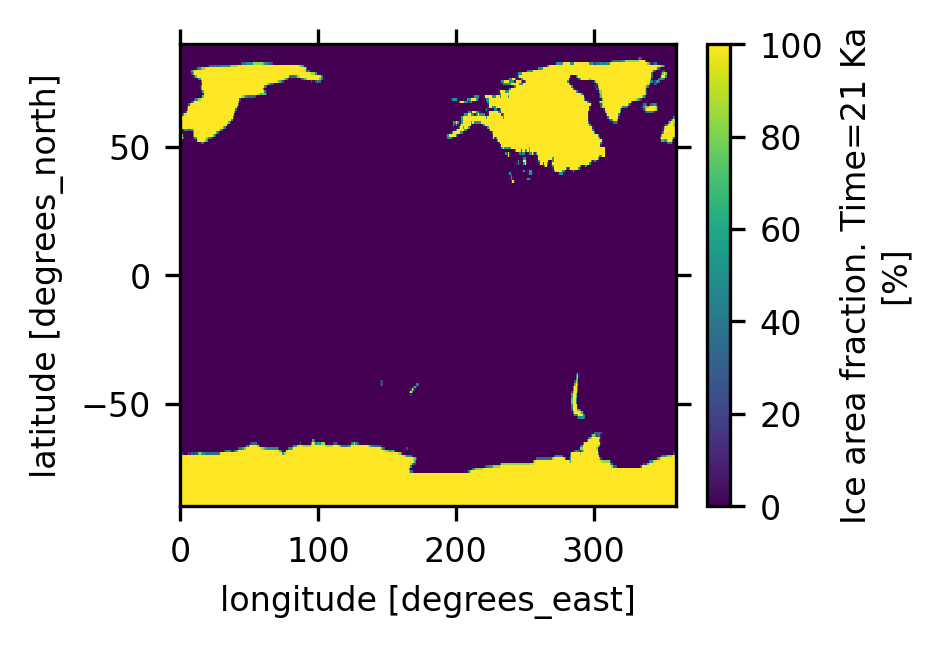

In [3]:
ds_i6g = xr.open_dataset('/glade/campaign/cesm/development/palwg/raw_boundary_data/ice-6g_c/I6_C.VM5a_1deg.21.nc')

ds_i6g.sftgif.plot(size=2)

---
## Helper functions
- Create grid x, y, lat, and lon with `laea` projection
- Save grid into netcdf
- Save SCRIP grid into netcdf
- Save ESMF grid into netcdf

In [4]:
# ── Build the grid ─────────────────────────────────────────────────────────
def make_grid(proj, x_min, x_max, y_min, y_max, dxy=4000):

    # Create regular x/y grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dxy),
                         np.arange(y_min, y_max, dxy))

    # Convert projection coords to lon/lat
    latlon   = Proj(proj='latlong', R=R_earth, units='m')
    to_latlon = Transformer.from_proj(proj, latlon, always_xy=True)
    lons, lats = to_latlon.transform(xx, yy)
    lons = np.where(lons < 0., lons + 360., lons)

    ny, nx = xx.shape
    print(f"Grid ny, nx : ({ny}, {nx}), ny/128={ny/128:.2f}, nx/128={nx/128:.2f}")
    print(f'Lat max, min: {lats.max()}, {lats.min()}')
    print(f'Lon max, min: {lons.max()}, {lons.min()}')
    return lats, lons, xx, yy


# ── Save grid to NetCDF ────────────────────────────────────────────────────
def save_grid(outFile, lats, lons, x, y):
    ny, nx = lats.shape
    ds = xr.Dataset(
        {
            'lon': xr.DataArray(
                lons.astype('f8'),
                dims=('ydim', 'xdim'),
                attrs={'long_name': 'longitude', 'units': 'degrees_east'}
            ),
            'lat': xr.DataArray(
                lats.astype('f8'),
                dims=('ydim', 'xdim'),
                attrs={'long_name': 'latitude', 'units': 'degrees_north'}
            ),
            'x1': xr.DataArray(
                x.astype('f8'),
                dims=('ydim', 'xdim'),
                attrs={'long_name': 'x-coordinate in projection', 'units': 'meters'}
            ),
            'y1': xr.DataArray(
                y.astype('f8'),
                dims=('ydim', 'xdim'),
                attrs={'long_name': 'y-coordinate in projection', 'units': 'meters'}
            ),
        },
        coords={
            'ydim': np.arange(ny),
            'xdim': np.arange(nx),
        },
        attrs={'Conventions': 'CF-1.8', 'coordinates': 'lat lon'},
    )
    ds.to_netcdf(outFile, format='NETCDF3_64BIT')
    print(f'Saved GRID: {outFile}')


# ── Save to SCRIP Grid ───────────────────────────────────────────────────────
def save_scrip(outFile, proj, lats, lons, x, y, dxy=4000):
    ny, nx = lats.shape
    latlon = Proj(proj='latlong', R=R_earth, units='m')
    to_latlon = Transformer.from_proj(proj, latlon, always_xy=True)

    # Compute corners in projection space
    half = dxy / 2.
    sw_lon, sw_lat = to_latlon.transform(x - half, y - half)
    se_lon, se_lat = to_latlon.transform(x + half, y - half)
    ne_lon, ne_lat = to_latlon.transform(x + half, y + half)
    nw_lon, nw_lat = to_latlon.transform(x - half, y + half)

    corner_lats = np.stack([sw_lat, se_lat, ne_lat, nw_lat], axis=-1)
    corner_lons = np.stack([sw_lon, se_lon, ne_lon, nw_lon], axis=-1)

    # Wrap corners near center to avoid 0/360 jumps
    c = lons.reshape(-1, 1)
    corner_lons = corner_lons.reshape(-1, 4)
    corner_lons = np.where(corner_lons - c >  180., corner_lons - 360., corner_lons)
    corner_lons = np.where(corner_lons - c < -180., corner_lons + 360., corner_lons)

    ds = xr.Dataset(
        {
            'grid_center_lat': xr.DataArray(
                lats.flatten().astype('f8'),
                dims=('grid_size',),
                attrs={'units': 'degrees'}
            ),
            'grid_center_lon': xr.DataArray(
                lons.flatten().astype('f8'),
                dims=('grid_size',),
                attrs={'units': 'degrees'}
            ),
            'grid_corner_lat': xr.DataArray(
                corner_lats.reshape(-1, 4).astype('f8'),
                dims=('grid_size', 'grid_corners'),
                attrs={'units': 'degrees'}
            ),
            'grid_corner_lon': xr.DataArray(
                corner_lons.reshape(-1, 4).astype('f8'),
                dims=('grid_size', 'grid_corners'),
                attrs={'units': 'degrees'}
            ),
            'grid_area': xr.DataArray(
                np.full(ny * nx, dxy**2 / R_earth**2, dtype='f8'),
                dims=('grid_size',),
                attrs={
                    'units': 'radians^2',
                    'long_name': 'cell area'
                }
            ),
            'grid_imask': xr.DataArray(
                np.ones(ny * nx, dtype='i4'),
                dims=('grid_size',),
                attrs={'units': 'unitless'}
            ),
            'grid_dims': xr.DataArray(
                np.array([nx, ny], dtype='i4'),
                dims=('grid_rank',)
            ),
        },
        coords={
            'grid_size': np.arange(ny*nx),
            'grid_corners': np.arange(4),
            'grid_rank': np.arange(2),
        },
        attrs={'title': 'SCRIP grid file', 'Conventions': 'SCRIP'},
    )
    ds.to_netcdf(outFile, format='NETCDF3_64BIT')
    print(f'Saved SCRIP: {outFile}')


# ── Save to ESMF MESH ────────────────────────────────────────────────────────
def save_esmf_mesh(outFile, proj, lats, lons, x, y, dxy=4000):
    ny, nx = lats.shape
    latlon = Proj(proj='latlong', R=R_earth, units='m')
    to_latlon = Transformer.from_proj(proj, latlon, always_xy=True)

    half = dxy / 2.0

    # Build node grid from projected cell edges
    # x varies only along columns, y only along rows (regular meshgrid)
    x_edges = np.concatenate([x[0, :] - half, [x[0, -1] + half]])
    y_edges = np.concatenate([y[:, 0] - half, [y[-1, 0] + half]])
    xe, ye = np.meshgrid(x_edges, y_edges)   # (ny+1, nx+1)
    node_lon, node_lat = to_latlon.transform(xe, ye)
    node_lon = np.where(node_lon < 0.0, node_lon + 360.0, node_lon)
    n_elem = ny * nx

    # Element connectivity, 1-based and counterclockwise: SW, SE, NE, NW
    j, i = np.mgrid[0:ny, 0:nx]
    sw = j       * (nx + 1) + i       + 1
    se = j       * (nx + 1) + (i + 1) + 1
    ne = (j + 1) * (nx + 1) + (i + 1) + 1
    nw = (j + 1) * (nx + 1) + i       + 1
    conn = np.stack([sw, se, ne, nw], axis=-1).reshape(n_elem, 4)
    ds = xr.Dataset(
        {
            'nodeCoords': xr.DataArray(
                np.stack([node_lon.reshape(-1), node_lat.reshape(-1)], axis=-1).astype('f8'),
                dims=('nodeCount', 'coordDim'),
                attrs={'units': 'degrees'}
            ),
            'elementConn': xr.DataArray(
                conn.astype('i4'),
                dims=('elementCount', 'maxNodePElement'),
                attrs={
                    'long_name': 'Node indices for each element',
                    'start_index': 1,
                }
            ),
            'numElementConn': xr.DataArray(
                np.full(n_elem, 4, dtype='i4'),
                dims=('elementCount',),
                attrs={'long_name': 'Number of nodes per element'}
            ),
            'centerCoords': xr.DataArray(
                np.stack([lons.reshape(-1), lats.reshape(-1)], axis=-1).astype('f8'),
                dims=('elementCount', 'coordDim'),
                attrs={'units': 'degrees'}
            ),
            'elementArea': xr.DataArray(
                np.full(n_elem, dxy**2 / R_earth**2, dtype='f8'),
                dims=('elementCount',),
                attrs={'units': 'radians^2'}
            ),
            'elementMask': xr.DataArray(
                np.ones(n_elem, dtype='i4'),
                dims=('elementCount',)
            ),
        },
        attrs={
            'gridType':        'unstructured',
            'version':         '0.9',
            'timeGenerated':   time.strftime('%Y-%m-%d %H:%M:%S'),
            'coordSys':        'SPH_DEG',
        },
    )
    ds.to_netcdf(outFile, format='NETCDF3_64BIT')
    print(f'Saved ESMF mesh: {outFile}')


# ── Plot the grid ──────────────────────────────────────────────────────────────
def plot_grid(lats, lons, ice_frac, e=10, cen_lat=90, cen_lon=-40):
    lat = lats[::e, ::e]
    lon = lons[::e, ::e]

    fig = plt.figure(figsize=(4, 4))
    ax  = fig.add_subplot(
        1, 1, 1,
        projection=ccrs.Stereographic(central_latitude=cen_lat, central_longitude=cen_lon)
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.scatter(lon, lat, s=0.1, transform=ccrs.PlateCarree())
    ax.contour(ice_frac.lon, ice_frac.lat, ice_frac, transform=ccrs.PlateCarree())


---
## Create a grid for the North American and Greenland ice sheets
- Tune the following 6 numbers to focus: central coordinates and bounds in meters
- It is better if nx and ny are multiples of 128 (cpus per node on Derecho)

In [5]:
ice_str = 'NAIS_GrIS'

cen_lat = 65
cen_lon = 270
x_min = -4108000  # The left edge
x_max =  3060000  # The right edge
y_min = -3300000  # The bottom edge
y_max =  2842000  # The top edge

Grid ny, nx : (1536, 1792), ny/128=12.00, nx/128=14.00
Lat max, min: 89.9818652643758, 23.39336632546638
Lon max, min: 359.9999103513222, 5.196361496538548e-05
Saved GRID: /glade/work/jiangzhu/data/inputdata/cesm3_21ka/NAIS_GrIS_laea_4km_260430.nc
Saved SCRIP: /glade/work/jiangzhu/data/inputdata/cesm3_21ka/NAIS_GrIS_laea_4km_260430_scrip.nc
Saved ESMF mesh: /glade/work/jiangzhu/data/inputdata/cesm3_21ka/NAIS_GrIS_laea_4km_260430_mesh.nc


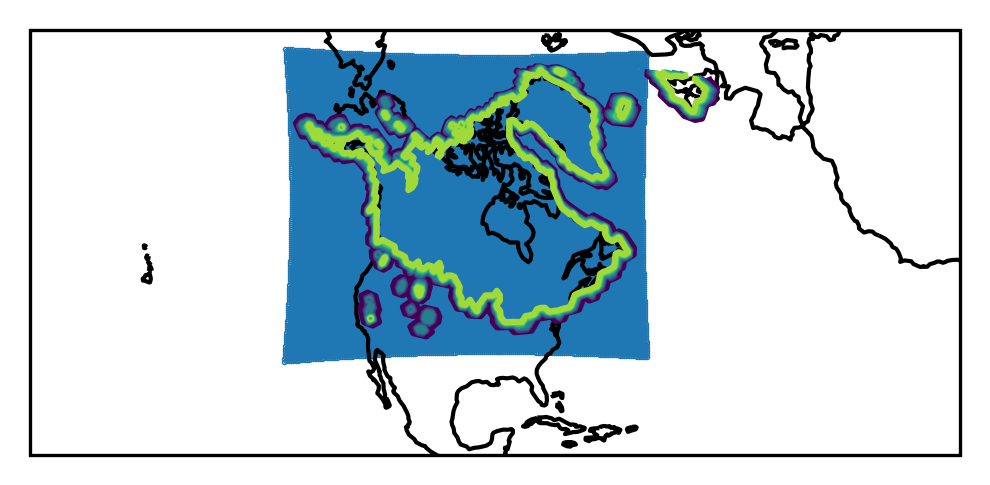

In [6]:

# Output files
grid_file = work_dir / f'{ice_str}_laea_{int(dxy/1000)}km_{today}.nc'
scrip_file = work_dir / f'{ice_str}_laea_{int(dxy/1000)}km_{today}_scrip.nc'
mesh_file = work_dir / f'{ice_str}_laea_{int(dxy/1000)}km_{today}_mesh.nc'

# Create projection
proj = Proj(proj='laea', lat_0=cen_lat, lon_0=cen_lon, R=R_earth, units='m')

# Create grid
lats, lons, x, y = make_grid(proj, x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, dxy=dxy)

# Make plot to check
ice_frac = ds_i6g.sftgif.sel(lat=slice(20, 90), lon=slice(180, 360), drop=True)
plot_grid(lats=lats, lons=lons, ice_frac=ice_frac, cen_lat=cen_lat, cen_lon=cen_lon)

# Save files
save_grid(grid_file, lats, lons, x, y)
save_scrip(scrip_file, proj, lats, lons, x, y, dxy)
save_esmf_mesh(mesh_file, proj, lats, lons, x, y, dxy)

---
## Create a grid for the European ice sheets

In [7]:
ice_str = 'EurIS'

cen_lat = 75
cen_lon = 45
x_min = -3700000  # The left edge
x_max =  2442000  # The right edge
y_min = -2600000  # The bottom edge
y_max =  1496000  # The top edge

Grid ny, nx : (1024, 1536), ny/128=8.00, nx/128=12.00
Lat max, min: 88.4482641805581, 38.59926553476566
Lon max, min: 359.99999464230046, 5.4079273783285475e-06
Saved GRID: /glade/work/jiangzhu/data/inputdata/cesm3_21ka/EurIS_laea_4km_260430.nc
Saved SCRIP: /glade/work/jiangzhu/data/inputdata/cesm3_21ka/EurIS_laea_4km_260430_scrip.nc
Saved ESMF mesh: /glade/work/jiangzhu/data/inputdata/cesm3_21ka/EurIS_laea_4km_260430_mesh.nc


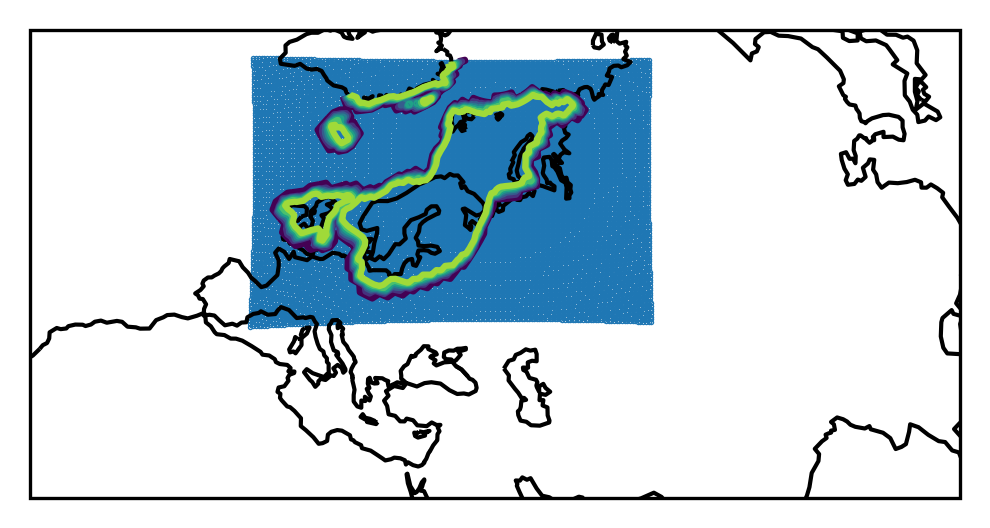

In [8]:

# Output files
grid_file = work_dir / f'{ice_str}_laea_{int(dxy/1000)}km_{today}.nc'
scrip_file = work_dir / f'{ice_str}_laea_{int(dxy/1000)}km_{today}_scrip.nc'
mesh_file = work_dir / f'{ice_str}_laea_{int(dxy/1000)}km_{today}_mesh.nc'

# Create projection
proj = Proj(proj='laea', lat_0=cen_lat, lon_0=cen_lon, R=R_earth, units='m')

# Create grid
lats, lons, x, y = make_grid(proj, x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, dxy=dxy)

# Make plot to check
ds_i6g_plot = ds_i6g.assign_coords(lon=((ds_i6g.lon + 180) % 360) - 180).sortby('lon')
ice_frac = ds_i6g_plot.sftgif.sel(lat=slice(30, 90), lon=slice(-30, 120), drop=True)
plot_grid(lats=lats, lons=lons, ice_frac=ice_frac, cen_lat=cen_lat, cen_lon=cen_lon)

# Save files
save_grid(grid_file, lats, lons, x, y)
save_scrip(scrip_file, proj, lats, lons, x, y, dxy)
save_esmf_mesh(mesh_file, proj, lats, lons, x, y, dxy)